# Fixture-level ensemble model

Ensemble model that takes in 2024/25 fixture data along with the pre-season and in-season models


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import shap


from training.config import MAX_HORIZON, RANDOM_STATE, TARGET_COLUMN
from training.transformations import create_ensemble_training_df
from prediction.artifacts.io import save_trained_catboost_model
from prediction.artifacts.io import ENSEMBLE_ARTIFACT_PATH


# Load 2024/25 fixture data

In [2]:
training_df = create_ensemble_training_df(
    season="2024-25",
    pre_season="2023-24",
)
validation_df = create_ensemble_training_df(
    season="2025-26",
    pre_season="2024-25",
)

In [3]:
validation_df.shape

(29747, 283)

# Train model

In [4]:
CATEGORICAL_COLUMNS = [
    "team",
    "position",
    # "current_gw",
    "target_gw",
    # "horizon",
    "was_home",
    "player_game_difficulty",
    "opponent_game_difficulty"
]

model_features = CATEGORICAL_COLUMNS + [
    "pre_season_model_score",
    "in_season_model_score",
]


In [5]:
X_train = training_df[model_features].copy()
y_train = training_df[TARGET_COLUMN].copy()
X_valid = validation_df[model_features].copy()
y_valid = validation_df[TARGET_COLUMN].copy()

for model_df in (X_train, X_valid):
    model_df[CATEGORICAL_COLUMNS] = (
        model_df[CATEGORICAL_COLUMNS].fillna("__MISSING__").astype(str)
    )

print(f"Training rows: {len(X_train):,}; validation rows: {len(X_valid):,}")

Training rows: 27,605; validation rows: 29,747


In [6]:
models = {}

In [7]:
def fit_catboost(sample_weight=None):
    fitted_model = CatBoostRegressor(
        iterations=163,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )
    fitted_model.fit(
        X_train,
        y_train,
        cat_features=CATEGORICAL_COLUMNS,
        sample_weight=sample_weight,
    )
    return fitted_model

unweighted_model = fit_catboost()
models["Unweighted"] = unweighted_model
validation_df["unweighted_model_score"] = unweighted_model.predict(X_valid)

In [8]:
# Give high-scoring returns extra influence during training.
basic_weights = pd.Series(1.0, index=y_train.index)
basic_weights.loc[y_train > 6] = 4.0

basic_weighting_model = fit_catboost(sample_weight=basic_weights)
models["Basic weighting"] = basic_weighting_model
validation_df["basic_weighting_model_score"] = (
    basic_weighting_model.predict(X_valid)
)

In [9]:
score_percentiles = (
    training_df.groupby(["season", "target_gw"])[
        TARGET_COLUMN
    ]
    .rank(pct=True, method="average")
)
percentile_weights = pd.cut(
    score_percentiles,
    bins=[0, 0.25, 0.50, 0.75, 0.90, 1.0],
    labels=[1.0, 1.5, 2.0, 3.0, 4.0],
    include_lowest=True,
).astype(float)

percentile_weighting_model = fit_catboost(
    sample_weight=percentile_weights
)
models["Percentile weighting"] = percentile_weighting_model
validation_df["percentile_weighting_model_score"] = (
    percentile_weighting_model.predict(X_valid)
)

# Evaluate models

In [10]:
pre_season_player_scores_df = training_df[
    ["season", "player_id", "position", "pre_season_model_score"]
].drop_duplicates(["season", "player_id"])

pre_season_score_by_position = (
    pre_season_player_scores_df.groupby("position")["pre_season_model_score"]
    .median()
)
pre_season_score_fallback = pre_season_player_scores_df[
    "pre_season_model_score"
].median()

validation_df["pre_season_model_score_with_fallback"] = (
    validation_df["pre_season_model_score"]
    .fillna(validation_df["position"].map(pre_season_score_by_position))
    .fillna(pre_season_score_fallback)
)

MODEL_SCORE_COLUMNS = {
    "Pre-season only": "pre_season_model_score_with_fallback",
    "In-season only": "in_season_model_score",
    "Unweighted": "unweighted_model_score",
    "Basic weighting": "basic_weighting_model_score",
    "Percentile weighting": "percentile_weighting_model_score",
}

print(
    f"Comparing models on all {len(validation_df):,} validation rows; "
    f"{validation_df['pre_season_model_score'].isna().sum():,} rows use the "
    "pre-season fallback"
)

def evaluate_predictions(prediction_column, top_fraction=0.10):
    evaluation_df = validation_df[
        ["season", "target_gw", TARGET_COLUMN, prediction_column]
    ].rename(columns={
        TARGET_COLUMN: "actual",
        prediction_column: "predicted",
    })

    top_decile_results = []
    for _, fixture_gameweek_df in evaluation_df.groupby(
        ["season", "target_gw"]
    ):
        top_decile_size = max(
            1, int(np.ceil(len(fixture_gameweek_df) * top_fraction))
        )
        predicted_top_df = fixture_gameweek_df.nlargest(
            top_decile_size, "predicted"
        )
        actual_top_indices = set(
            fixture_gameweek_df.nlargest(top_decile_size, "actual").index
        )
        top_decile_results.append({
            "top_decile_avg_actual_points": predicted_top_df["actual"].mean(),
            "top_decile_hit_rate": predicted_top_df.index.isin(
                actual_top_indices
            ).mean(),
            "top_decile_oracle_regret": (
                fixture_gameweek_df.nlargest(top_decile_size, "actual")["actual"].mean()
                - predicted_top_df["actual"].mean()
            ),
        })

    top_decile_metrics = pd.DataFrame(top_decile_results).mean()
    return {
        "MAE": mean_absolute_error(evaluation_df["actual"], evaluation_df["predicted"]),
        "RMSE": root_mean_squared_error(evaluation_df["actual"], evaluation_df["predicted"]),
        "R2": r2_score(evaluation_df["actual"], evaluation_df["predicted"]),
        **top_decile_metrics.to_dict(),
    }

comparison_table = (
    pd.DataFrame.from_dict(
        {
            model_name: evaluate_predictions(prediction_column)
            for model_name, prediction_column in MODEL_SCORE_COLUMNS.items()
        },
        orient="index",
    )
    .rename_axis("model")
    .reset_index()
    .sort_values("top_decile_avg_actual_points", ascending=False)
    .reset_index(drop=True)
)

comparison_table.round(3)

Comparing models on all 29,747 validation rows; 12,193 rows use the pre-season fallback


,model,MAE,RMSE,R2,top_decile_avg_actual_points,top_decile_hit_rate,top_decile_oracle_regret
0,Percentile weighting,1.156,1.972,0.297,3.763,0.352,3.380
1,Basic weighting,1.239,2.079,0.219,3.736,0.349,3.407
2,Unweighted,0.979,1.957,0.308,3.728,0.348,3.415
3,In-season only,1.029,1.986,0.287,3.585,0.328,3.558
4,Pre-season only,1.452,2.257,0.079,2.783,0.247,4.360


## Shap values

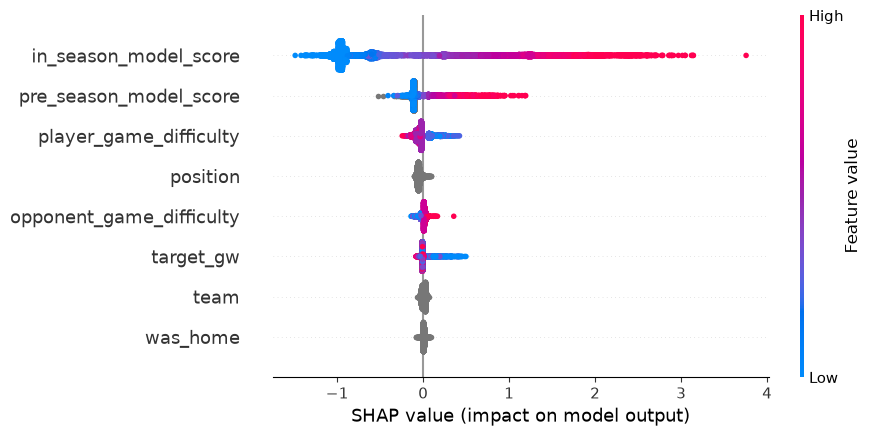

In [11]:
shap_explainer = shap.TreeExplainer(unweighted_model)

shap_sample_df = X_valid.sample(
    n=min(10_000, len(X_valid)),
    random_state=RANDOM_STATE,
)

shap_values = shap_explainer(shap_sample_df)

shap.plots.beeswarm(
    shap_values,
    max_display=len(model_features),
)

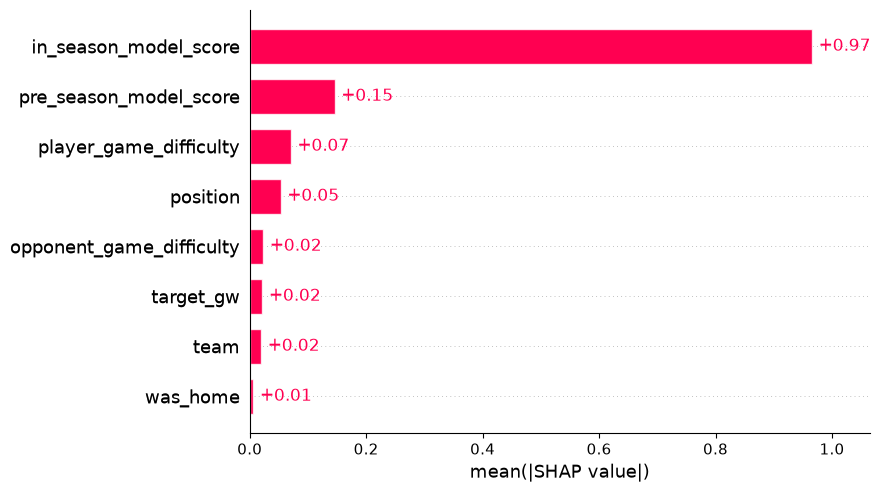

In [12]:
shap.plots.bar(
    shap_values,
    max_display=len(model_features),
)

## Does game difficulty split above models?

# Export

In [13]:
save_trained_catboost_model(
    model=unweighted_model,
    feature_columns=model_features,
    categorical_columns=CATEGORICAL_COLUMNS,
    model_name='ensemble_unweighted',
    model_version='0.1.0',
    save_path=ENSEMBLE_ARTIFACT_PATH
)